<a href="https://colab.research.google.com/github/TienPhap0102/02-TheLook-Ecommerce-Analysis/blob/main/TheLook_Ecommcerce_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **THE LOOK ECOMERCE PROJECT**

## **1. Set up & Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

## **2. Data Processing**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **2.1. `Order table`**

In [ ]:
orders = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 10 - 11: Project/Dataset/orders.csv')
orders.head()

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,7,8,Cancelled,F,2023-09-06 10:43:00 UTC,NaN,NaN,NaN,1
1,40,36,Cancelled,F,2023-07-08 04:49:00 UTC,NaN,NaN,NaN,2
2,43,37,Cancelled,F,2023-12-04 05:29:00 UTC,NaN,NaN,NaN,1
3,59,50,Cancelled,F,2022-03-21 08:06:00 UTC,NaN,NaN,NaN,1
4,77,63,Cancelled,F,2024-02-04 15:21:00 UTC,NaN,NaN,NaN,1


In [ ]:
orders.groupby(by = 'status').count()

,order_id,user_id,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
status,,,,,,,,
Cancelled,18679,18679,18679,18679,0,0,0,18679
Complete,31428,31428,31428,31428,0,31428,31428,31428
Processing,24681,24681,24681,24681,0,0,0,24681
Returned,12439,12439,12439,12439,12439,12439,12439,12439
Shipped,37587,37587,37587,37587,0,37587,0,37587


In [ ]:
completed_orders = orders[orders['status'] == 'Complete']
display(completed_orders.head())

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
9315,1,1,Complete,F,2023-10-26 08:20:00 UTC,NaN,2023-10-26 20:22:00 UTC,2023-10-30 02:36:00 UTC,2
9316,6,8,Complete,F,2023-07-19 10:43:00 UTC,NaN,2023-07-21 16:55:00 UTC,2023-07-23 16:54:00 UTC,1
9317,13,12,Complete,F,2020-02-23 07:02:00 UTC,NaN,2020-02-24 18:58:00 UTC,2020-02-25 18:30:00 UTC,1
9318,14,12,Complete,F,2021-08-03 07:02:00 UTC,NaN,2021-08-05 18:15:00 UTC,2021-08-10 12:45:00 UTC,2
9319,18,17,Complete,F,2021-01-17 01:50:00 UTC,NaN,2021-01-18 17:27:00 UTC,2021-01-20 06:47:00 UTC,1


In [ ]:
# Data overview
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124814 entries, 0 to 124813
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   order_id      124814 non-null  int64 
 1   user_id       124814 non-null  int64 
 2   status        124814 non-null  object
 3   gender        124814 non-null  object
 4   created_at    124814 non-null  object
 5   returned_at   12439 non-null   object
 6   shipped_at    81454 non-null   object
 7   delivered_at  43867 non-null   object
 8   num_of_item   124814 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 8.6+ MB


In [ ]:
# Check duplicated
orders.duplicated().sum()

np.int64(0)

In [ ]:
# Check null
orders.isnull().sum()

,0
order_id,0
user_id,0
status,0
gender,0
created_at,0
returned_at,112375
shipped_at,43360
delivered_at,80947
num_of_item,0


**Key Findings:**

* The dataset contains 124,814 order records.

* There are no duplicate records within the orders table.

* The presence of null values in the returned_at, shipped_at, and delivered_at columns is logically sound, as they consistently align with the order status column.

* While the data types for the majority of columns are appropriate, a few specific columns (`created_at`, `returned_at`, `shipped_at`, `delivered_at`) require formatting.

**Action:** Strip the 'UTC' suffix and convert these fields to the datetime data type.

In [ ]:
# Remove the 'UTC' suffix from the created_at, returned_at, shipped_at, and delivered_at columns.
orders['created_at'] = orders['created_at'].str.replace(' UTC', '')
orders['returned_at'] = orders['returned_at'].str.replace(' UTC', '')
orders['shipped_at'] = orders['shipped_at'].str.replace(' UTC', '')
orders['delivered_at'] = orders['delivered_at'].str.replace(' UTC', '')

In [ ]:
# Cast data types to datetime format
orders['created_at'] = orders['created_at'].astype('datetime64[ns]')
orders['returned_at'] = orders['returned_at'].astype('datetime64[ns]')
orders['shipped_at'] = orders['shipped_at'].astype('datetime64[ns]')
orders['delivered_at'] = orders['delivered_at'].astype('datetime64[ns]')

In [ ]:
# Validate data types
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124814 entries, 0 to 124813
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      124814 non-null  int64         
 1   user_id       124814 non-null  int64         
 2   status        124814 non-null  object        
 3   gender        124814 non-null  object        
 4   created_at    124814 non-null  datetime64[ns]
 5   returned_at   12439 non-null   datetime64[ns]
 6   shipped_at    81454 non-null   datetime64[ns]
 7   delivered_at  43867 non-null   datetime64[ns]
 8   num_of_item   124814 non-null  int64         
dtypes: datetime64[ns](4), int64(3), object(2)
memory usage: 8.6+ MB


In [ ]:
fig = px.box(orders, x = 'num_of_item')
fig.show()

A **single outlier** was identified; however, it has **no significant impact** on the overall data integrity

### **2.2. `Order Items table`**

In [ ]:
order_items = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 10 - 11: Project/Dataset/order_items.csv')
order_items.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,101104,69639,55545,14235,273075,Cancelled,2021-12-27 23:35:57 UTC,NaN,NaN,NaN,0.02
1,17970,12402,9819,14235,48492,Complete,2024-01-21 08:21:43 UTC,2024-01-19 18:09:00 UTC,2024-01-21 09:20:00 UTC,NaN,0.02
2,46481,32099,25651,14235,125372,Complete,2019-10-06 06:14:19 UTC,2019-10-03 13:08:00 UTC,2019-10-04 01:04:00 UTC,NaN,0.02
3,162654,112208,89828,14235,439099,Processing,2022-12-11 00:43:18 UTC,NaN,NaN,NaN,0.02
4,61938,42730,34156,14235,167190,Returned,2023-09-20 11:58:48 UTC,2023-09-23 14:58:00 UTC,2023-09-25 07:58:00 UTC,2023-09-28 00:40:00 UTC,0.02


In [ ]:
# Data overview
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180862 entries, 0 to 180861
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 180862 non-null  int64  
 1   order_id           180862 non-null  int64  
 2   user_id            180862 non-null  int64  
 3   product_id         180862 non-null  int64  
 4   inventory_item_id  180862 non-null  int64  
 5   status             180862 non-null  object 
 6   created_at         180862 non-null  object 
 7   shipped_at         117919 non-null  object 
 8   delivered_at       63463 non-null   object 
 9   returned_at        18041 non-null   object 
 10  sale_price         180862 non-null  float64
dtypes: float64(1), int64(5), object(5)
memory usage: 15.2+ MB


In [ ]:
# Check duplicate
order_items.duplicated().sum()

np.int64(0)

In [ ]:
# Check null
order_items.isnull().sum()

,0
id,0
order_id,0
user_id,0
product_id,0
inventory_item_id,0
status,0
created_at,0
shipped_at,62943
delivered_at,117399
returned_at,162821


In [ ]:
# Column stats
order_items.describe().T

,count,mean,std,min,25%,50%,75%,max
id,180862.0,90431.500000,52210.506530,1.00,45216.250000,90431.500000,135646.750000,180862.0
order_id,180862.0,62356.999464,36012.944090,1.00,31234.250000,62276.000000,93560.750000,124814.0
user_id,180862.0,49854.956519,28860.914818,1.00,24946.000000,49664.000000,74855.000000,100000.0
product_id,180862.0,15312.442426,8403.317188,1.00,8050.250000,16045.000000,22569.000000,29120.0
inventory_item_id,180862.0,244129.185257,140940.835701,2.00,121970.750000,244175.000000,366223.500000,488146.0
sale_price,180862.0,59.693776,66.880191,0.02,24.950001,39.990002,69.949997,999.0


**Key findings:**

* The dataset contains a total of 180.862 records.

* There are no duplicate records within the order items table.

* The presence of null values in the `returned_at`, `shipped_at`, and `delivered_at` columns is logically sound, as they consistently align with the order `status` column.

* While the data types for the majority of columns are appropriate, a few specific columns require formatting.

* The sale_price column was identified as potentially containing outliers.

In [ ]:
# Remove the 'UTC' suffix from the created_at, returned_at, shipped_at, and delivered_at columns.
order_items['created_at'] = order_items['created_at'].str.replace(' UTC', '')
order_items['returned_at'] = order_items['returned_at'].str.replace(' UTC', '')
order_items['shipped_at'] = order_items['shipped_at'].str.replace(' UTC', '')
order_items['delivered_at'] = order_items['delivered_at'].str.replace(' UTC', '')

In [ ]:
# Cast data types to datetime format.
order_items['created_at'] = order_items['created_at'].astype('datetime64[ns]')
order_items['returned_at'] = order_items['returned_at'].astype('datetime64[ns]')
order_items['shipped_at'] = order_items['shipped_at'].astype('datetime64[ns]')
order_items['delivered_at'] = order_items['delivered_at'].astype('datetime64[ns]')

In [ ]:
# Validate data types
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180862 entries, 0 to 180861
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 180862 non-null  int64         
 1   order_id           180862 non-null  int64         
 2   user_id            180862 non-null  int64         
 3   product_id         180862 non-null  int64         
 4   inventory_item_id  180862 non-null  int64         
 5   status             180862 non-null  object        
 6   created_at         180862 non-null  datetime64[ns]
 7   shipped_at         117919 non-null  datetime64[ns]
 8   delivered_at       63463 non-null   datetime64[ns]
 9   returned_at        18041 non-null   datetime64[ns]
 10  sale_price         180862 non-null  float64       
dtypes: datetime64[ns](4), float64(1), int64(5), object(1)
memory usage: 15.2+ MB


In [ ]:
# Check outlier in sale_price
# Box plot
fig = px.box(order_items, x = 'sale_price')
fig.show()

In [ ]:
# Quantitle
Q1 = order_items['sale_price'].quantile(0.25)
Q3 = order_items['sale_price'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Initialize the 'Outlier_check' column with 'Normal'
order_items['Outlier_check'] = 'Normal'
# Mark outliers as 'Outlier'
order_items.loc[(order_items['sale_price'] < lower_bound) | (order_items['sale_price'] > upper_bound), 'Outlier_check'] = 'Outlier'
order_items.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,Outlier_check
0,101104,69639,55545,14235,273075,Cancelled,2021-12-27 23:35:57,NaT,NaT,NaT,0.02,Normal
1,17970,12402,9819,14235,48492,Complete,2024-01-21 08:21:43,2024-01-19 18:09:00,2024-01-21 09:20:00,NaT,0.02,Normal
2,46481,32099,25651,14235,125372,Complete,2019-10-06 06:14:19,2019-10-03 13:08:00,2019-10-04 01:04:00,NaT,0.02,Normal
3,162654,112208,89828,14235,439099,Processing,2022-12-11 00:43:18,NaT,NaT,NaT,0.02,Normal
4,61938,42730,34156,14235,167190,Returned,2023-09-20 11:58:48,2023-09-23 14:58:00,2023-09-25 07:58:00,2023-09-28 00:40:00,0.02,Normal


In [ ]:
# Calculate Outlier group and Normal group
order_items.groupby(by = 'Outlier_check').agg(num_order = ('order_id', 'nunique'))

,num_order
Outlier_check,
Normal,117134
Outlier,15003


**Key findings:**

These outliers are likely inherent to the product pricing structure; therefore, they will be retained in the dataset for analysis.

### **2.3. `Product table`**

In [ ]:
products = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 10 - 11: Project/Dataset/products.csv')
products.head()

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1
1,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1
2,14115,4.87956,Accessories,Enzyme Regular Solid Army Caps-Black W35S45D,MG,10.99,Women,EE364229B2791D1EF9355708EFF0BA34,1
3,14157,4.64877,Accessories,Enzyme Regular Solid Army Caps-Olive W35S45D (...,MG,10.99,Women,00BD13095D06C20B11A2993CA419D16B,1
4,14273,6.50793,Accessories,Washed Canvas Ivy Cap - Black W11S64C,MG,15.99,Women,F531DC20FDE20B7ADF3A73F52B71D0AF,1


In [ ]:
products[['id','category','name', 'retail_price']].sort_values(by = 'retail_price', ascending = True)

,id,category,name,retail_price
1401,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,0.02
2300,14159,Accessories,Set of 2 - Replacement Insert For Checkbook Wa...,0.49
23027,28700,Accessories,Wayfarer Style Sunglasses Dark Lens Black Frame,1.50
11644,14202,Accessories,GENUINE LEATHER SNAP ON STUDDED WHITE PIANO BE...,1.50
28484,13629,Accessories,Solid Color Leather Adjustable Skinny Belt with,1.51
...,...,...,...,...
27810,24201,Outerwear & Coats,Mens Nike AirJordan Varsity Hoodie Jacket Grey...,903.00
11939,24341,Outerwear & Coats,Nobis Yatesy Parka,950.00
22948,24110,Outerwear & Coats,Woolrich Arctic Parka DF,990.00
16169,24447,Outerwear & Coats,Darla,999.00


In [ ]:
# Data overview
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29120 entries, 0 to 29119
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      29120 non-null  int64  
 1   cost                    29120 non-null  float64
 2   category                29120 non-null  object 
 3   name                    29118 non-null  object 
 4   brand                   29096 non-null  object 
 5   retail_price            29120 non-null  float64
 6   department              29120 non-null  object 
 7   sku                     29120 non-null  object 
 8   distribution_center_id  29120 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 2.0+ MB


In [ ]:
# Check duplicate
products.duplicated().sum()

np.int64(0)

In [ ]:
# Check null
products.isnull().sum()

,0
id,0
cost,0
category,0
name,2
brand,24
retail_price,0
department,0
sku,0
distribution_center_id,0


**Key Findings:**

* The dataset comprises 29,120 unique product items.

* No duplicate records were identified within the dataset.

* There are no null values present, ensuring complete data availability.

* All data types are appropriate and consistent with their respective fields.

### **2.4. `User table`**

In [ ]:
users = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 10 - 11: Project/Dataset/users.csv')
users.head()

,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at
0,8142,Dean,Vance,deanvance@example.net,50,M,Acre,8821 Wolf Trail,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2022-10-30 17:46:00 UTC
1,24645,Michael,Turner,michaelturner@example.org,28,M,Acre,600 Monica Fort Apt. 260,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2022-08-08 13:16:00 UTC
2,34950,Shari,Medina,sharimedina@example.net,59,F,Acre,98922 Villarreal Brook,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2023-09-26 05:11:00 UTC
3,37723,Matthew,Dunn,matthewdunn@example.net,16,M,Acre,724 Michele Island Apt. 077,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2019-06-13 18:09:00 UTC
4,43283,Michael,Stevens,michaelstevens@example.net,70,M,Acre,220 Butler Lake Suite 506,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2023-07-24 14:57:00 UTC


In [ ]:
# Data overview
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              100000 non-null  int64  
 1   first_name      100000 non-null  object 
 2   last_name       100000 non-null  object 
 3   email           100000 non-null  object 
 4   age             100000 non-null  int64  
 5   gender          100000 non-null  object 
 6   state           100000 non-null  object 
 7   street_address  100000 non-null  object 
 8   postal_code     100000 non-null  object 
 9   city            99045 non-null   object 
 10  country         100000 non-null  object 
 11  latitude        100000 non-null  float64
 12  longitude       100000 non-null  float64
 13  traffic_source  100000 non-null  object 
 14  created_at      100000 non-null  object 
dtypes: float64(2), int64(2), object(11)
memory usage: 11.4+ MB


In [ ]:
# Check duplicate
users.duplicated().sum()

np.int64(0)

In [ ]:
# Check null
users.isnull().sum()

,0
id,0
first_name,0
last_name,0
email,0
age,0
gender,0
state,0
street_address,0
postal_code,0
city,955


**Key Findings:**

* The dataset comprises 100,000 unique user records.

* No duplicate entries were identified, ensuring the uniqueness of the user base.

* Null values were detected in the `city` column and have been categorized as '**Unknown**' to maintain data consistency.

* While the majority of columns feature appropriate data types, the `created_at` field required standardization. **Removed the 'UTC' suffix and successfully cast the created_at column to the datetime format.**

In [ ]:
# Replace null values in the city column with 'Unknown'
users['city'] = users['city'].fillna('Unknown')

In [ ]:
# Remove UTC in created_at
users['created_at'] = users['created_at'].str.replace(' UTC', '')

In [ ]:
# Validate
users['created_at'] = users['created_at'].astype('datetime64[ns]')

In [ ]:
# Validate
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              100000 non-null  int64         
 1   first_name      100000 non-null  object        
 2   last_name       100000 non-null  object        
 3   email           100000 non-null  object        
 4   age             100000 non-null  int64         
 5   gender          100000 non-null  object        
 6   state           100000 non-null  object        
 7   street_address  100000 non-null  object        
 8   postal_code     100000 non-null  object        
 9   city            100000 non-null  object        
 10  country         100000 non-null  object        
 11  latitude        100000 non-null  float64       
 12  longitude       100000 non-null  float64       
 13  traffic_source  100000 non-null  object        
 14  created_at      100000 non-null  date

### **2.5. `Event table`**

In [ ]:
events = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 10 - 11: Project/Dataset/events.csv')
events.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1437486,NaN,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00 UTC,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
1,2172013,NaN,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00 UTC,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
2,1987970,NaN,3,1f918350-992c-49dd-82af-f3e72b8b94e4,2021-02-17 04:35:00 UTC,91.237.188.129,São Paulo,São Paulo,02675-031,Safari,Email,/cancel,cancel
3,2245378,NaN,3,8a99bc3c-f70b-4c9a-be26-5313bb226b34,2024-04-07 04:52:00 UTC,147.219.220.175,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
4,1519935,NaN,3,a64f434d-d3f2-4261-a490-79d4743d81e4,2023-09-14 15:20:00 UTC,211.175.27.209,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel


In [ ]:
# Data overview
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2420661 entries, 0 to 2420660
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               int64  
 1   user_id          float64
 2   sequence_number  int64  
 3   session_id       object 
 4   created_at       object 
 5   ip_address       object 
 6   city             object 
 7   state            object 
 8   postal_code      object 
 9   browser          object 
 10  traffic_source   object 
 11  uri              object 
 12  event_type       object 
dtypes: float64(1), int64(2), object(10)
memory usage: 240.1+ MB


In [ ]:
# Check duplicate
events.duplicated().sum()

np.int64(0)

In [ ]:
# Check null
events.isnull().sum()

,0
id,0
user_id,1124527
sequence_number,0
session_id,0
created_at,0
ip_address,0
city,22537
state,0
postal_code,0
browser,0


In [ ]:
events.groupby(by = 'event_type').count()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri
event_type,,,,,,,,,,,,
cancel,124801,0,124801,124801,124801,124801,123579,124801,124801,124801,124801,124801
cart,592374,342622,592374,592374,592374,592374,586937,592374,592374,592374,592374,592374
department,592596,342622,592596,592596,592596,592596,587145,592596,592596,592596,592596,592596
home,87406,87406,87406,87406,87406,87406,86561,87406,87406,87406,87406,87406
product,842622,342622,842622,842622,842622,842622,834687,842622,842622,842622,842622,842622
purchase,180862,180862,180862,180862,180862,180862,179215,180862,180862,180862,180862,180862


**Key findings:**

* The dataset comprises a total of 2,420,661 records.

* A thorough validation confirmed that there are no duplicate records present in the dataset.

* There are 1,124,527 null values identified in the user_id column, which likely represent customers who have not registered an account on the platform. **Action:** Assign a value of 0 (labeled as 'Guest') to these null entries to maintain data consistency.

* Replace the 22,537 missing values in the city column with the label 'Unknown'.

* All existing data types are appropriate and align with the expected data schema.

In [ ]:
# Removed UTC in created_at
events['created_at'] = events['created_at'].str.replace(' UTC', '')

In [ ]:
# Cast data types to datetime format
events['created_at'] = events['created_at'].astype('datetime64[ns]')

In [ ]:
# user_id = 0 for NaN value
events['user_id'] = events['user_id'].fillna(0)

# city = Unknown for NaN value
events['city'] = events['city'].fillna('Unknown')

In [ ]:
# Validate data types
events.isnull().sum()

,0
id,0
user_id,0
sequence_number,0
session_id,0
created_at,0
ip_address,0
city,0
state,0
postal_code,0
browser,0


In [ ]:
print('The data has been thoroughly cleansed and is now ready for analysis')

The data has been thoroughly cleansed and is now ready for analysis


## **3. Key Performance Metrics**

#### **3.1. Trend Analysis**

In [ ]:
order_items.head(2)

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,Outlier_check
0,101104,69639,55545,14235,273075,Cancelled,2021-12-27 23:35:57,NaT,NaT,NaT,0.02,Normal
1,17970,12402,9819,14235,48492,Complete,2024-01-21 08:21:43,2024-01-19 18:09:00,2024-01-21 09:20:00,NaT,0.02,Normal


In [ ]:
products.head(2)

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1
1,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1


In [ ]:
events.head(2)

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1437486,0.0,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
1,2172013,0.0,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel


In [ ]:
# Add column Month/Year
order_items['month'] = order_items['created_at'].dt.to_period('M')
events['month'] = events['created_at'].dt.to_period('M')

In [ ]:
# Merge order_items & products
order_items_prd = order_items.merge(products[['id', 'cost']], how = 'left', left_on = 'product_id', right_on = 'id')
order_items_prd.head(2)

,id_x,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,Outlier_check,month,id_y,cost
0,101104,69639,55545,14235,273075,Cancelled,2021-12-27 23:35:57,NaT,NaT,NaT,0.02,Normal,2021-12,14235,0.0083
1,17970,12402,9819,14235,48492,Complete,2024-01-21 08:21:43,2024-01-19 18:09:00,2024-01-21 09:20:00,NaT,0.02,Normal,2024-01,14235,0.0083


In [ ]:
# Metrics: Revenue, Profit, Orders, AOV
# Dimension: month
trend_metrics = order_items_prd.groupby(by = 'month').agg(Revenue = ('sale_price', 'sum'),
                                                          Cost = ('cost', 'sum'),
                                                           Orders = ('order_id', 'nunique'))

trend_metrics['Profit'] = trend_metrics['Revenue'] - trend_metrics['Cost']
trend_metrics['AOV'] = trend_metrics['Revenue'] / trend_metrics['Orders']
trend_metrics

,Revenue,Cost,Orders,Profit,AOV
month,,,,,
2019-01,1238.819995,561.849560,13,676.970435,95.293846
2019-02,2390.240008,1220.129375,36,1170.110633,66.395556
2019-03,7089.289995,3380.003749,84,3709.286245,84.396309
2019-04,9934.070022,4925.251889,103,5008.818133,96.447282
2019-05,12040.160010,5578.381339,140,6461.778672,86.001143
...,...,...,...,...,...
2024-01,468036.380438,225120.373740,5539,242916.006698,84.498354
2024-02,496183.940308,238036.431906,5813,258147.508402,85.357636
2024-03,594568.650664,285998.286362,7122,308570.364301,83.483383


In [ ]:
# Calculate the total number of sessions.
session_events = events.groupby(by = 'month').agg(Sessions = ('session_id', 'nunique'))
session_events

,Sessions
month,
2019-01,7673
2019-02,7195
2019-03,8095
2019-04,7808
2019-05,8128
...,...
2024-01,15974
2024-02,15979
2024-03,18259


In [ ]:
# Merge trend_metric & session-events
trend_metrics = trend_metrics.merge(session_events, how = 'left', left_on = 'month', right_on = 'month')
trend_metrics

,Revenue,Cost,Orders,Profit,AOV,Sessions
month,,,,,,
2019-01,1238.819995,561.849560,13,676.970435,95.293846,7673
2019-02,2390.240008,1220.129375,36,1170.110633,66.395556,7195
2019-03,7089.289995,3380.003749,84,3709.286245,84.396309,8095
2019-04,9934.070022,4925.251889,103,5008.818133,96.447282,7808
2019-05,12040.160010,5578.381339,140,6461.778672,86.001143,8128
...,...,...,...,...,...,...
2024-01,468036.380438,225120.373740,5539,242916.006698,84.498354,15974
2024-02,496183.940308,238036.431906,5813,258147.508402,85.357636,15979
2024-03,594568.650664,285998.286362,7122,308570.364301,83.483383,18259


In [ ]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter(x=trend_metrics.index.astype(str), y=trend_metrics['Revenue'], name="Revenue"),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=trend_metrics.index.astype(str), y=trend_metrics['Profit'], name="Profit"),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=trend_metrics.index.astype(str), y=trend_metrics['Sessions'], name="Sessions"),
    secondary_y=True,
)

# Add figure title
fig.update_layout(
    title_text="Monthly Revenue, Profit, and Sessions Trend"
)

# Set x-axis title
fig.update_xaxes(title_text="Month")

# Set y-axes titles
fig.update_yaxes(title_text="<b>Revenue/Profit</b> (USD)", secondary_y=False)
fig.update_yaxes(title_text="<b>Sessions</b>", secondary_y=True)

fig.show()

### **3.2. Business Overview**

Key Performance Metrics Calculation:

* Total Revenue

* Total Profit

* Transaction Volume / Total Number of Transactions

* Average Order Value (AOV)

* Return Rate

* Conversion Rate

* Traffic Performance by Source / Traffic Acquisition Performance


In [ ]:
total_revenue = trend_metrics['Revenue'].sum()
total_profit = trend_metrics['Profit'].sum()
total_orders = trend_metrics['Orders'].sum()
total_sessions = trend_metrics['Sessions'].sum()
total_aov = total_revenue / total_orders

# Calculate Return Rate
returned_orders_count = orders[orders['status'] == 'Returned'].shape[0]
total_orders_count = orders.shape[0]
return_rate = (returned_orders_count / total_orders_count) * 100

# Calculate Conversion Rate
conversion_rate = (total_orders / total_sessions) * 100

# Calculate Profit Margin
profit_margin = (total_profit / total_revenue) * 100

# Calculate Total Returned Amount
total_returned_amount = order_items[order_items['status'] == 'Returned']['sale_price'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Sessions: {total_sessions:,}")
print(f"Average Order Value (AOV): ${total_aov:,.2f}")
print(f"Return Rate: {return_rate:.2f}%")
print(f"Conversion Rate: {conversion_rate:.2f}%")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Returned Amount: ${total_returned_amount:,.2f}")

Total Revenue: $10,796,335.70
Total Profit: $5,602,333.55
Total Orders: 127,194
Total Sessions: 686,993
Average Order Value (AOV): $84.88
Return Rate: 9.97%
Conversion Rate: 18.51%
Profit Margin: 51.89%
Total Returned Amount: $1,076,166.12


## **4. Revenue Analysis**

**Objective:** Conduct a Pareto Analysis to identify the core product group, specifically those comprising the **top 20% of inventory** that **contributes to 80% of the total revenue**.

In [ ]:
# Complete, Shipped, Processing orders
df_order_items = order_items[order_items['status'].isin(['Complete', 'Shipped', 'Processing'])]

# Merge df_order_items & product
df_order_items = df_order_items.merge(products[['id', 'category']], how = 'left', left_on = 'product_id', right_on = 'id')
df_order_items.head(2)

,id_x,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,Outlier_check,month,id_y,category
0,17970,12402,9819,14235,48492,Complete,2024-01-21 08:21:43,2024-01-19 18:09:00,2024-01-21 09:20:00,NaT,0.02,Normal,2024-01,14235,Accessories
1,46481,32099,25651,14235,125372,Complete,2019-10-06 06:14:19,2019-10-03 13:08:00,2019-10-04 01:04:00,NaT,0.02,Normal,2019-10,14235,Accessories


In [ ]:
# Groupby & sorting
df_agg_pareto = df_order_items.groupby(by = 'category').agg(Revenue = ('sale_price', 'sum'),
                                                            Total_orders = ('order_id','nunique')
                                                            ).sort_values(by = 'Revenue', ascending = False)
df_agg_pareto

,Revenue,Total_orders
category,,
Outerwear & Coats,995916.559134,6499
Jeans,948292.671238,9348
Sweaters,618647.770221,8000
Fashion Hoodies & Sweatshirts,482737.070437,8649
Swim,480350.320708,8189
Suits & Sport Coats,469628.389503,3679
Sleep & Lounge,425442.960981,8265
Shorts,396422.051053,8217
Tops & Tees,366724.111220,8620


In [ ]:
# % Contribution & cumsum
total_revenue = df_agg_pareto['Revenue'].sum()
df_agg_pareto['Contribution'] = df_agg_pareto['Revenue'] / total_revenue
df_agg_pareto['cumulative_revenue'] = df_agg_pareto['Contribution'].cumsum()
df_agg_pareto

,Revenue,Total_orders,Contribution,cumulative_revenue
category,,,,
Outerwear & Coats,995916.559134,6499,0.123005,0.123005
Jeans,948292.671238,9348,0.117123,0.240129
Sweaters,618647.770221,8000,0.076409,0.316538
Fashion Hoodies & Sweatshirts,482737.070437,8649,0.059623,0.376160
Swim,480350.320708,8189,0.059328,0.435488
Suits & Sport Coats,469628.389503,3679,0.058004,0.493492
Sleep & Lounge,425442.960981,8265,0.052546,0.546038
Shorts,396422.051053,8217,0.048962,0.595000
Tops & Tees,366724.111220,8620,0.045294,0.640294


In [ ]:
# cut point
vital_few = df_agg_pareto[df_agg_pareto['cumulative_revenue'] <= 0.8]
print(f'Total products:', vital_few.shape[0])
print('-'*40)
print(f'Total Revenue:', vital_few['Revenue'].sum())
print('-'*40)

Total products: 12
----------------------------------------
Total Revenue: 6205472.025967598
----------------------------------------


In [ ]:
fig = make_subplots(rows=1, cols=1, specs=[[{"secondary_y": True}]])

# Add Bar chart for Revenue
fig.add_trace(
    go.Bar(x=df_agg_pareto.index, y=df_agg_pareto['Revenue'], name='Revenue by Category'),
    secondary_y=False,
)

# Add Line chart for Cumulative Revenue
fig.add_trace(
    go.Scatter(x=df_agg_pareto.index, y=df_agg_pareto['cumulative_revenue'], name='Cumulative Revenue', mode='lines+markers'),
    secondary_y=True,
)

# Add a line for the 80% cumulative revenue mark
fig.add_hline(y=0.8, line_dash="dot",
              annotation_text="80% Cumulative Revenue",
              annotation_position="bottom right",
              secondary_y=True)

# Customize layout
fig.update_layout(
    title_text="Pareto Chart of Revenue by Product Category",
    xaxis_title="Product Category",
    yaxis_title="Revenue",
    yaxis2_title="Cumulative Revenue Contribution"
)

# Format y-axis for percentage on cumulative revenue
fig.update_yaxes(tickformat=".0%", secondary_y=True)

fig.show()

### **Insight**
* The platform offers **26 product categories**; however, revenue is highly concentrated, with only **12 categories** (less than 50% of the total count) generating 76.64% of total revenue (**$6.2M**).

* The Value-driven group is led by **Outerwear & Coat**s, which generated **$995K in revenue** from only **6,499 orders**.

* The Volume-driven group, which drives traffic and engagement, is headlined by Jeans (**9,348 orders**) and Intimates (**9,296 orders**), the latter having an Average Order Value (AOV) of approximately **$36**.

However, the dominance of Outerwear & Coats, Sweaters, and Fashion Hoodies within the core product group suggests that the platform’s revenue is primarily seasonal, peaking during cold weather. Conversely, the mid-tier performance of Swimwear indicates significant potential for summer-season growth if strategically optimized.

In [ ]:
selected_categories = ['Outerwear & Coats', 'Jeans', 'Swim']

# Filter df_order_items for selected categories
filtered_category_data = df_order_items[df_order_items['category'].isin(selected_categories)]

# Aggregate monthly revenue for each category
monthly_category_revenue = filtered_category_data.groupby(['month', 'category']).agg(Revenue=('sale_price', 'sum')).reset_index()

# Convert 'month' column to string for Plotly compatibility
monthly_category_revenue['month'] = monthly_category_revenue['month'].astype(str)

# Create the line chart
fig = px.line(monthly_category_revenue, x='month', y='Revenue', color='category',
             title='Monthly Revenue Trend for Selected Vital Categories',
             labels={'month': 'Month', 'Revenue': 'Revenue (USD)', 'category': 'Product Category'},
             markers=True) # Add markers to emphasize data points
fig.update_layout(hovermode='x unified') # Improve hover experience
fig.show()

## **5. Customer Segmentation (RFM analysis)**

In [ ]:
# Complete, Shipped, Processing orders
df_order_items = order_items[order_items['status'].isin(['Complete', 'Shipped', 'Processing'])]

df_RFM = df_order_items[['user_id', 'created_at', 'order_id','sale_price']]
df_RFM.head(2)

,user_id,created_at,order_id,sale_price
1,9819,2024-01-21 08:21:43,12402,0.02
2,25651,2019-10-06 06:14:19,32099,0.02


In [ ]:
df_rfm_groupby = df_RFM.groupby(by = 'user_id', as_index = False).agg(max_date = ('created_at','max'),
                                       Frequency = ('order_id', 'nunique'),
                                       Monetory = ('sale_price', 'sum'))
df_rfm_groupby['Recency'] = (dt.datetime.now() - df_rfm_groupby['max_date']).dt.days
df_rfm_groupby.head()

,user_id,max_date,Frequency,Monetory,Recency
0,1,2023-10-27 07:32:22,1,56.000000,933
1,2,2024-01-28 00:36:26,1,258.980000,841
2,6,2023-06-02 10:21:51,1,135.880005,1080
3,7,2024-04-08 04:01:53,1,80.599998,770
4,8,2023-07-19 07:29:03,1,24.690001,1033


In [ ]:
# Cut point
df_rfm_groupby['R_score'] = pd.qcut(df_rfm_groupby['Recency'],q = 5, labels=[5, 4, 3, 2, 1], duplicates = 'drop')
df_rfm_groupby['F_score'] = pd.qcut(df_rfm_groupby['Frequency'],q = 5, duplicates = 'drop')
df_rfm_groupby['M_score'] = pd.qcut(df_rfm_groupby['Monetory'],q = 5, labels=[1, 2, 3, 4, 5], duplicates = 'drop')
df_rfm_groupby.head(2)

,user_id,max_date,Frequency,Monetory,Recency,R_score,F_score,M_score
0,1,2023-10-27 07:32:22,1,56.00,933,4,"(0.999, 2.0]",2
1,2,2024-01-28 00:36:26,1,258.98,841,4,"(0.999, 2.0]",5


In [ ]:
df_rfm_groupby['R_score'].unique()

[4, 3, 5, 2, 1]
Categories (5, int64): [5 < 4 < 3 < 2 < 1]

In [ ]:
df_rfm_groupby['M_score'].unique()

[2, 5, 4, 3, 1]
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [ ]:
df_rfm_groupby['F_score'].unique()

[(0.999, 2.0], (2.0, 4.0]]
Categories (2, interval[float64, right]): [(0.999, 2.0] < (2.0, 4.0]]

In [ ]:
# Handling Frequency column
frequency_new = df_rfm_groupby[['Frequency']].drop_duplicates().sort_values(by='Frequency', ascending=True)
frequency_new['F_score_new'] = pd.qcut(frequency_new['Frequency'], q = 5, duplicates='drop')
frequency_new

,Frequency,F_score_new
0,1,"(0.999, 1.6]"
7,2,"(1.6, 2.2]"
31,3,"(2.8, 3.4]"
81,4,"(3.4, 4.0]"


In [ ]:
# Check F_score_new
frequency_new['F_score_new'].unique()
frequency_new['F_score_new'] = pd.qcut(frequency_new['Frequency'], q = 5, labels = [1,2,3,4,5], duplicates='drop')
frequency_new

,Frequency,F_score_new
0,1,1
7,2,2
31,3,4
81,4,5


In [ ]:
# Merge frequency_new & RFM
RFM = pd.merge(df_rfm_groupby, frequency_new, on='Frequency', how='left')
RFM.head(2)

,user_id,max_date,Frequency,Monetory,Recency,R_score,F_score,M_score,F_score_new
0,1,2023-10-27 07:32:22,1,56.00,933,4,"(0.999, 2.0]",2,1
1,2,2024-01-28 00:36:26,1,258.98,841,4,"(0.999, 2.0]",5,1


In [ ]:
# Add RFM column
RFM['RFM_Score'] = RFM['R_score'].astype(int) * 100 + RFM['F_score_new'].astype(int)*10 + RFM['M_score'].astype(int)
RFM.head(2)

,user_id,max_date,Frequency,Monetory,Recency,R_score,F_score,M_score,F_score_new,RFM_Score
0,1,2023-10-27 07:32:22,1,56.00,933,4,"(0.999, 2.0]",2,1,412
1,2,2024-01-28 00:36:26,1,258.98,841,4,"(0.999, 2.0]",5,1,415


In [ ]:
RFM['RFM_Segment'] = 'Other'  # Default label for rows not matching any segment

# Champions
RFM.loc[RFM['RFM_Score'].isin([555, 554, 544, 545, 454, 455, 445]), 'RFM_Segment'] = 'Champions'

# Loyal
RFM.loc[RFM['RFM_Score'].isin([543, 444, 435, 355, 354, 345, 344, 335]), 'RFM_Segment'] = 'Loyal'

# Potential Loyalist
RFM.loc[RFM['RFM_Score'].isin([553, 551, 552, 541, 542, 533, 532, 531, 452, 451
                                                 , 442, 441, 431, 453, 433, 432, 423, 353, 352
                                                 , 351, 342, 341, 333, 323]), 'RFM_Segment'] = 'Potential Loyalist'

# Promising
RFM.loc[RFM['RFM_Score'].isin([525, 524, 523, 522, 521, 515, 514, 513
                                                 , 425, 424, 413, 414, 415, 315, 314, 313]), 'RFM_Segment'] = 'Promising'

# New Customers
RFM.loc[RFM['RFM_Score'].isin([512, 511, 422, 421, 412, 411, 311]), 'RFM_Segment'] = 'New Customers'

# Need Attention
RFM.loc[RFM['RFM_Score'].isin([535, 534, 443, 434, 343, 334, 325, 324]), 'RFM_Segment'] = 'Need Attention'

# About To Sleep
RFM.loc[RFM['RFM_Score'].isin([331, 321, 312, 221, 213, 231, 241, 251]), 'RFM_Segment'] = 'About To Sleep'

# At Risk
RFM.loc[RFM['RFM_Score'].isin([255, 254, 245, 244, 253, 252, 243, 242, 235
                                                 , 234, 225, 224, 153, 152, 145, 143, 142
                                                 , 135, 134, 133, 125, 124]), 'RFM_Segment'] = 'At Risk'

# Cannot Lose Them
RFM.loc[RFM['RFM_Score'].isin([155, 154, 144, 214, 215, 115, 114, 113]), 'RFM_Segment'] = 'Cannot Lose Them'

# Hibernating customers
RFM.loc[RFM['RFM_Score'].isin([332, 322, 233, 232, 223, 222, 132, 123, 122, 212, 211]), 'RFM_Segment'] = 'Hibernating customers'

# Lost customers
RFM.loc[RFM['RFM_Score'].isin([111, 112, 121, 131, 141, 151]), 'RFM_Segment'] = 'Lost customers'

# Display the DataFrame with the new RFM_Segment column
RFM

,user_id,max_date,Frequency,Monetory,Recency,R_score,F_score,M_score,F_score_new,RFM_Score,RFM_Segment
0,1,2023-10-27 07:32:22.000000,1,56.000000,933,4,"(0.999, 2.0]",2,1,412,New Customers
1,2,2024-01-28 00:36:26.000000,1,258.980000,841,4,"(0.999, 2.0]",5,1,415,Promising
2,6,2023-06-02 10:21:51.000000,1,135.880005,1080,3,"(0.999, 2.0]",4,1,314,Promising
3,7,2024-04-08 04:01:53.000000,1,80.599998,770,5,"(0.999, 2.0]",3,1,513,Promising
4,8,2023-07-19 07:29:03.000000,1,24.690001,1033,3,"(0.999, 2.0]",1,1,311,New Customers
...,...,...,...,...,...,...,...,...,...,...,...
66210,99995,2023-10-20 13:46:26.000000,1,4.990000,940,3,"(0.999, 2.0]",1,1,311,New Customers
66211,99997,2024-04-01 06:58:00.000000,1,12.000000,776,5,"(0.999, 2.0]",1,1,511,New Customers
66212,99998,2024-05-13 00:35:48.807689,1,244.880001,735,5,"(0.999, 2.0]",5,1,515,Promising
66213,99999,2023-05-23 17:02:00.000000,2,83.990002,1090,3,"(0.999, 2.0]",3,2,323,Potential Loyalist


In [ ]:
RFM.groupby(by = 'RFM_Segment', as_index = False).agg(total_customers = ('user_id', 'nunique'),
                                                                 total_revenue = ('Monetory', 'sum')).sort_values(by = 'total_revenue', ascending = False)


,RFM_Segment,total_customers,total_revenue
10,Promising,17338,2.845155e+06
2,Cannot Lose Them,7910,1.331204e+06
3,Champions,2915,9.318508e+05
1,At Risk,3727,9.107073e+05
7,Need Attention,2222,4.854338e+05
6,Loyal,1546,3.746879e+05
8,New Customers,11494,3.429635e+05
4,Hibernating customers,7091,2.900539e+05
0,About To Sleep,4311,2.616706e+05
5,Lost customers,6108,1.956743e+05


In [ ]:
rfm_segment_monetary = RFM.groupby('RFM_Segment')['Monetory'].sum().reset_index()

fig = px.treemap(rfm_segment_monetary,
                 path=['RFM_Segment'],
                 values='Monetory',
                 title='RFM Segment Distribution by Monetary Value',
                 color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

In [ ]:
# Customers
rfm_segment_customers = RFM.groupby('RFM_Segment')['user_id'].nunique().reset_index()
rfm_segment_customers.rename(columns={'user_id': 'Total_Customers'}, inplace=True)

fig = px.treemap(rfm_segment_customers,
                 path=['RFM_Segment'],
                 values='Total_Customers',
                 title='RFM Segment Distribution by Number of Customers',
                 color_discrete_sequence=px.colors.qualitative.Plotly)

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

**Insight**

* Platform revenue is currently entirely dependent on continuous new customer acquisition. The majority of customers only complete **one or two transactions before churning**, failing to establish long-term purchasing habits.

* Over **13,000 customer**s have transitioned into '**Hibernating**' or '**Lost**' status. Most alarmingly, the '**Cannot Lose The**m' segment—which previously **contributed $1.33M** in total spend—has not engaged with the platform for an extended period.

## **6.Business Heath (Cohort analysis)**

In [ ]:
pre_cohort = order_items[['user_id', 'created_at']]
pre_cohort

,user_id,created_at
0,55545,2021-12-27 23:35:57
1,9819,2024-01-21 08:21:43
2,25651,2019-10-06 06:14:19
3,89828,2022-12-11 00:43:18
4,34156,2023-09-20 11:58:48
...,...,...
180857,91673,2023-10-12 07:10:05
180858,95471,2023-04-05 09:14:19
180859,17801,2023-11-18 02:54:51
180860,74060,2019-03-07 04:44:05


In [ ]:
first_purchase = pre_cohort.groupby(by = 'user_id', as_index = False).agg(First_Purchase = ('created_at', 'min'))
first_purchase['First_Purchase_Year'] = first_purchase['First_Purchase'].dt.to_period('Y')
first_purchase

,user_id,First_Purchase,First_Purchase_Year
0,1,2023-10-27 07:25:01.000000,2023
1,2,2024-01-25 00:30:06.000000,2024
2,5,2023-11-27 03:05:43.000000,2023
3,6,2023-06-02 10:21:51.000000,2023
4,7,2024-04-08 01:26:35.000000,2024
...,...,...,...
80090,99995,2023-10-20 13:46:26.000000,2023
80091,99997,2024-04-01 06:58:00.000000,2024
80092,99998,2024-05-10 01:06:56.807689,2024
80093,99999,2023-04-08 17:46:09.000000,2023


In [ ]:
# Join first_purchase with pre_cohort_sales
cohort_sales = pd.merge(pre_cohort, first_purchase[['user_id', 'First_Purchase', 'First_Purchase_Year']], on = 'user_id', how = 'left')
# Remove any lingering First_Purchase_Quarter column if it exists
if 'First_Purchase_Quarter' in cohort_sales.columns:
    cohort_sales = cohort_sales.drop(columns=['First_Purchase_Quarter'])
cohort_sales

,user_id,created_at,First_Purchase,First_Purchase_Year
0,55545,2021-12-27 23:35:57,2021-03-03 23:43:40,2021
1,9819,2024-01-21 08:21:43,2024-01-19 07:10:44,2024
2,25651,2019-10-06 06:14:19,2019-10-03 02:51:04,2019
3,89828,2022-12-11 00:43:18,2021-06-21 20:52:12,2021
4,34156,2023-09-20 11:58:48,2023-09-20 11:58:48,2023
...,...,...,...,...
180857,91673,2023-10-12 07:10:05,2023-10-11 05:07:41,2023
180858,95471,2023-04-05 09:14:19,2022-07-10 05:33:52,2022
180859,17801,2023-11-18 02:54:51,2022-09-10 03:44:40,2022
180860,74060,2019-03-07 04:44:05,2019-03-07 04:44:05,2019


In [ ]:
cohort_sales['Created_At_Year'] = cohort_sales['created_at'].dt.to_period('Y')
cohort_sales['Cohort_Year'] = (cohort_sales['Created_At_Year'] - cohort_sales['First_Purchase_Year']).apply(lambda x: x.n)
cohort_sales

,user_id,created_at,First_Purchase,First_Purchase_Year,Created_At_Year,Cohort_Year
0,55545,2021-12-27 23:35:57,2021-03-03 23:43:40,2021,2021,0
1,9819,2024-01-21 08:21:43,2024-01-19 07:10:44,2024,2024,0
2,25651,2019-10-06 06:14:19,2019-10-03 02:51:04,2019,2019,0
3,89828,2022-12-11 00:43:18,2021-06-21 20:52:12,2021,2022,1
4,34156,2023-09-20 11:58:48,2023-09-20 11:58:48,2023,2023,0
...,...,...,...,...,...,...
180857,91673,2023-10-12 07:10:05,2023-10-11 05:07:41,2023,2023,0
180858,95471,2023-04-05 09:14:19,2022-07-10 05:33:52,2022,2023,1
180859,17801,2023-11-18 02:54:51,2022-09-10 03:44:40,2022,2023,1
180860,74060,2019-03-07 04:44:05,2019-03-07 04:44:05,2019,2019,0


In [ ]:
cohort_sales_pivot = cohort_sales.pivot_table(index = 'First_Purchase_Year', columns = 'Cohort_Year', values = 'user_id', aggfunc = 'nunique')
cohort_sales_pivot

Cohort_Year,0,1,2,3,4,5
First_Purchase_Year,,,,,,
2019,2090.0,368.0,376.0,390.0,384.0,170.0
2020,6608.0,1298.0,1271.0,1324.0,476.0,NaN
2021,11009.0,2476.0,2496.0,977.0,NaN,NaN
2022,16939.0,4630.0,1930.0,NaN,NaN,NaN
2023,26048.0,4929.0,NaN,NaN,NaN,NaN
2024,17401.0,NaN,NaN,NaN,NaN,NaN


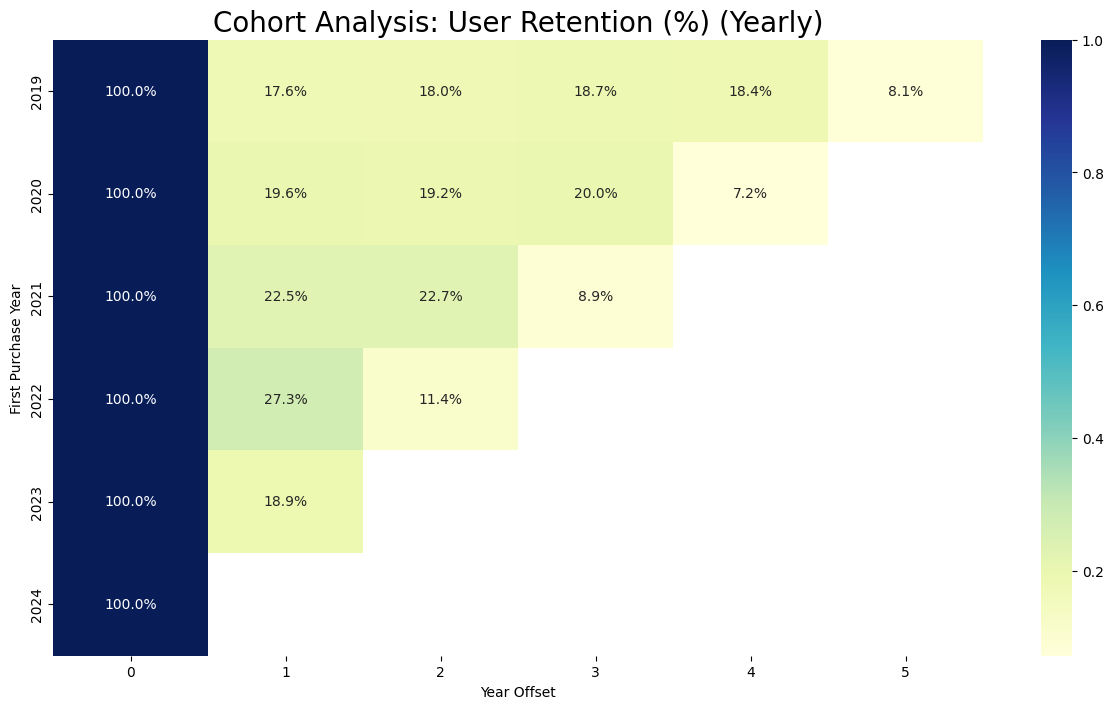

In [ ]:
# Retention Matrix (tỷ lệ %)
cohort_sizes = cohort_sales_pivot.iloc[:, 0]
retention_matrix = cohort_sales_pivot.divide(cohort_sizes, axis=0)

# 2. Heatmap
plt.figure(figsize=(15, 8)) # Adjusted figure size for yearly cohorts
plt.title('Cohort Analysis: User Retention (%) (Yearly)', fontsize=20)

sns.heatmap(retention_matrix.iloc[:, :], # Displaying all available years
            annot=True,
            fmt='.1%',
            cmap='YlGnBu'
           )

plt.xlabel('Year Offset')
plt.ylabel('First Purchase Year')
plt.show()

**Key findings Cohort Chart:**

*   Multi-year cohort analysis exposes a chronic, platform-wide retention deficit across all historical brackets. Upon entering Year 1 (the first year post-acquisition), the platform experiences an immediate and severe drop-off, with retention capped at a stagnant 18% – 27% range, followed by a continuous decay in subsequent years.

**Empirical Evidence (Data Proof-Points):**

* **2019 Cohort:** Retention collapsed to **17.6% in Year 1** and progressively degraded to a marginal **8.1% by Year 5**.

* **2020 Cohort:** Replicated an identical decay curve, capturing only **19.6% in Year 1** and **dropping** to a trough of **7.2% by Year 4**.

* **2023 Cohort (Most Recent Complete Cycle):** Re-validates this structural ceiling at **18.9% in Year 1**, proving that the retention bottleneck remains entirely unresolved.

### **Insight**

The combined RFM and Cohort analysis strongly refutes the hypothesis that the platform's success is driven by customer loyalty. Instead, it highlights a critical over-reliance on continuous new customer acquisition and a significant struggle with long-term retention.

*   **RFM analysis** reveals that 'New Customers' and 'Promising' segments are the primary revenue drivers, accounting for approximately **29,000 individuals**. Conversely, the loyal 'Champions' segment is exceptionally small. This indicates that while the platform excels at attracting new users, most customers complete only one or two transactions before churning.

*   **Cohort analysis** further validates this retention challenge, demonstrating a severe, platform-wide retention deficit. User retention plummets dramatically, typically to a stagnant **18% – 27% by the second year (Cohort Year 1)**, with continuous decay in subsequent years. This near-total attrition of existing customers confirms that they do not form a sustainable foundation for the platform's long-term revenue, aligning with previous RFM analysis findings regarding a systemic challenge in engaging customers beyond initial transactions.

## **7. Sankey Flow**


In [ ]:
events.head(2)

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type,month
0,1437486,0.0,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel,2019-04
1,2172013,0.0,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel,2022-10


In [ ]:
# events
events_pc = events[events['event_type'].isin(['purchase', 'cancel'])].dropna(subset=['user_id'])
events_pc

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type,month
0,1437486,0.0,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel,2019-04
1,2172013,0.0,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel,2022-10
2,1987970,0.0,3,1f918350-992c-49dd-82af-f3e72b8b94e4,2021-02-17 04:35:00,91.237.188.129,São Paulo,São Paulo,02675-031,Safari,Email,/cancel,cancel,2021-02
3,2245378,0.0,3,8a99bc3c-f70b-4c9a-be26-5313bb226b34,2024-04-07 04:52:00,147.219.220.175,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel,2024-04
4,1519935,0.0,3,a64f434d-d3f2-4261-a490-79d4743d81e4,2023-09-14 15:20:00,211.175.27.209,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel,2023-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2420656,250019,19311.0,7,53867936-aa38-4560-9465-b75767c216e6,2023-12-21 13:06:26,12.243.127.22,Wednesbury,England,WS10,Chrome,Email,/purchase,purchase,2023-12
2420657,618279,47247.0,13,ed14c8b0-1cfb-49e0-9a6c-d21d39b29fe9,2023-10-02 14:45:24,8.55.144.64,Walsall,England,WS2,Chrome,Adwords,/purchase,purchase,2023-10
2420658,1221035,94065.0,7,c1cd8f89-109b-4a5c-87f5-2be2e80008f5,2023-11-08 07:48:08,41.91.14.89,York,England,YO10,Other,Email,/purchase,purchase,2023-11
2420659,1240623,95575.0,5,18d51715-95a6-4d61-89c8-768ce498ed5d,2024-03-01 09:04:11,124.152.229.183,York,England,YO24,Firefox,Organic,/purchase,purchase,2024-03


In [ ]:
# leyer 1 (Traffic -> Purchase / Cancel)
layer1 = events_pc.groupby(['traffic_source', 'event_type']).size().reset_index(name='value')
layer1.columns = ['source', 'target', 'value']
layer1

,source,target,value
0,Adwords,cancel,37412
1,Adwords,purchase,54072
2,Email,cancel,55997
3,Email,purchase,81364
4,Facebook,cancel,12678
5,Facebook,purchase,18343
6,Organic,cancel,6165
7,Organic,purchase,8911
8,YouTube,cancel,12549
9,YouTube,purchase,18172


In [ ]:
# layer 2 (Purchase / Cancel -> Category)
merged_df = events_pc.merge(order_items[['user_id', 'product_id']], on='user_id', how='left')
merged_df = merged_df.merge(products[['id','category']], on='id', how='left')
merged_df.head(2)

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type,month,product_id,category
0,1437486,0.0,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel,2019-04,NaN,NaN
1,2172013,0.0,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel,2022-10,NaN,NaN


In [ ]:
# top 5 category
top_5_cats = merged_df['category'].value_counts().nlargest(5).index.tolist()
top_5_cats

merged_df['category_grouped'] = merged_df['category'].apply(lambda x: x if x in top_5_cats else 'Others')
merged_df

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type,month,product_id,category,category_grouped
0,1437486,0.0,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel,2019-04,NaN,NaN,Others
1,2172013,0.0,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel,2022-10,NaN,NaN,Others
2,1987970,0.0,3,1f918350-992c-49dd-82af-f3e72b8b94e4,2021-02-17 04:35:00,91.237.188.129,São Paulo,São Paulo,02675-031,Safari,Email,/cancel,cancel,2021-02,NaN,NaN,Others
3,2245378,0.0,3,8a99bc3c-f70b-4c9a-be26-5313bb226b34,2024-04-07 04:52:00,147.219.220.175,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel,2024-04,NaN,NaN,Others
4,1519935,0.0,3,a64f434d-d3f2-4261-a490-79d4743d81e4,2023-09-14 15:20:00,211.175.27.209,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel,2023-09,NaN,NaN,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738430,1240623,95575.0,5,18d51715-95a6-4d61-89c8-768ce498ed5d,2024-03-01 09:04:11,124.152.229.183,York,England,YO24,Firefox,Organic,/purchase,purchase,2024-03,2424.0,NaN,Others
738431,1240623,95575.0,5,18d51715-95a6-4d61-89c8-768ce498ed5d,2024-03-01 09:04:11,124.152.229.183,York,England,YO24,Firefox,Organic,/purchase,purchase,2024-03,10710.0,NaN,Others
738432,1240623,95575.0,5,18d51715-95a6-4d61-89c8-768ce498ed5d,2024-03-01 09:04:11,124.152.229.183,York,England,YO24,Firefox,Organic,/purchase,purchase,2024-03,10158.0,NaN,Others
738433,516543,39603.0,7,098cbc99-54e6-481f-9bb5-75841c104219,2023-07-25 14:09:51,115.159.87.213,Selby,England,YO8,Chrome,Adwords,/purchase,purchase,2023-07,9450.0,NaN,Others


In [ ]:
# group layer 2
layer2 = merged_df.groupby(['event_type', 'category_grouped']).size().reset_index(name='value')
layer2.columns = ['source', 'target', 'value']
layer2

,source,target,value
0,cancel,Others,124801
1,purchase,Fashion Hoodies & Sweatshirts,967
2,purchase,Intimates,1202
3,purchase,Jeans,889
4,purchase,Others,608782
5,purchase,Sleep & Lounge,907
6,purchase,Tops & Tees,887


In [ ]:
sankey_df = pd.concat([layer1, layer2], ignore_index=True)

all_nodes = list(pd.unique(sankey_df[['source', 'target']].values.ravel('K')))
node_dict = {node: i for i, node in enumerate(all_nodes)}

sankey_df['source_id'] = sankey_df['source'].map(node_dict)
sankey_df['target_id'] = sankey_df['target'].map(node_dict)

node_colors = ['#FF4B4B' if node == 'cancel' else '#28A745' if node == 'purchase' else '#808080' for node in all_nodes]
link_colors = ['rgba(255, 75, 75, 0.4)' if src == 'cancel' else 'rgba(40, 167, 69, 0.4)' if src == 'purchase' else 'rgba(200, 200, 200, 0.3)' for src in sankey_df['source']]

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20, thickness = 25,
      line = dict(color = "blue", width = 0.5),
      label = all_nodes,
      color = node_colors
    ),
    link = dict(
      source = sankey_df['source_id'],
      target = sankey_df['target_id'],
      value = sankey_df['value'],
      color = link_colors
  ))])

fig.update_layout(title_text="<b>Analysis of Conversion Flow & Loss by Source and Category</b>", font_size=13, height=650)
fig.show()

### **Insight**
* Data indicates that when calculating the Cancellation Rate defined as **Cancellations / (Cancellations + Purchases)** across all acquisition channels:

  * Email: ~40.7%
  
  * Adwords: ~40.8%

  * Facebook: ~40.8%

  * YouTube: ~40.8%

  * Organic: ~40.8%

The **cancellation rate** remains stagnant at approximately **41%** regardless of the traffic source. This suggests that the issue does not stem from ineffective marketing targeting, but rather from systemic or operational inefficiencies within The Look.

* **Email continues to be the dominant channel**, generating the highest volume of purchases at **81,364 units**. This significantly outperforms paid advertising channels such as Adwords (**54,072 units**) and Facebook (**18,343 units**).

In [ ]:
df_orders_products = pd.merge(order_items[['product_id', 'sale_price', 'status']], products[['id', 'category']], left_on='product_id', right_on='id', how='inner')

# Top 5 Category
top_5_cats = df_orders_products['category'].value_counts().nlargest(5).index.tolist()
df_orders_products['category_grouped'] = df_orders_products['category'].apply(lambda x: x if x in top_5_cats else 'Others')

# Category -> Order Status
sankey_data = df_orders_products.groupby(['category_grouped', 'status']).size().reset_index(name='value')
sankey_data.columns = ['source', 'target', 'value']

#  Sankey flow
all_nodes = list(pd.unique(sankey_data[['source', 'target']].values.ravel('K')))
node_dict = {node: i for i, node in enumerate(all_nodes)}

sankey_data['source_id'] = sankey_data['source'].map(node_dict)
sankey_data['target_id'] = sankey_data['target'].map(node_dict)

node_colors = ['#28A745' if node == 'Complete' else '#DC3545' if node in ['Returned', 'Cancelled'] else '#FFC107' if node in ['Processing', 'Shipped'] else '#1f77b4' for node in all_nodes]

fig = go.Figure(data=[go.Sankey(
    node = dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=all_nodes, color=node_colors),
    link = dict(source=sankey_data['source_id'], target=sankey_data['target_id'], value=sankey_data['value'])
)])
fig.update_layout(title_text="<b>Order Status Map by Product Category</b>", font_size=13, height=600)
fig.show()

**Insight**

* The Top 5 core categories maintain a relatively stable Cancellation/Return rate **between 24% and 27%**. In contrast, the "**Others**" category exhibits a critical failure rate of **nearly 60%** (124,890 defective units out of 209,608 total units purchased). More significantly, this "Others" group accounts for 91.9% of all cancelled orders across the entire platform.

* Despite achieving the highest conversion rates, the absolute loss value from the top two categories remains substantial:

  * **Intimates:** 2,932 units cancelled and 2,480 units returned (compared to 4,975 successful fulfillments).

  * **Jeans:** 1,890 units cancelled and 1,590 units returned (compared to 3,197 successful fulfillments).

In [ ]:
import pandas as pd

# Create a DataFrame with relevant funnel events and user activity for the calculation
# Considering 'product' as the initial step for the journey being analyzed for failure rates
funnel_data = events[events['event_type'].isin(['product', 'cart', 'purchase'])].copy()

# Calculate unique sessions at each step for each traffic source
funnel_counts = funnel_data.groupby(['traffic_source', 'event_type'])['session_id'].nunique().unstack(fill_value=0)

# Ensure all required columns exist, fill missing with 0 (for cases where a traffic source might not have a specific event)
required_events = ['product', 'cart', 'purchase']
for event in required_events:
    if event not in funnel_counts.columns:
        funnel_counts[event] = 0

# Calculate Total_Sessions (sessions that reached the 'product' step)
# This is considered the starting point for the 'Product -> Cart -> Purchase' funnel
funnel_counts['Total_Sessions'] = funnel_counts['product']

# Calculate drop-off rates
# Using fillna(0) to handle cases where the denominator might be 0, resulting in 0% drop-off (as no one entered that stage)
funnel_counts['Product -> Cart (% Drop-off)'] = (1 - (funnel_counts['cart'] / funnel_counts['product'])).fillna(0) * 100
funnel_counts['Cart -> Purchase (% Drop-off)'] = (1 - (funnel_counts['purchase'] / funnel_counts['cart'])).fillna(0) * 100
funnel_counts['Total Journey Failure Rate'] = (1 - (funnel_counts['purchase'] / funnel_counts['product'])).fillna(0) * 100

# Select and format the output columns, rounding to 1 decimal place
funnel_failure_rates = funnel_counts[[
    'Total_Sessions',
    'Product -> Cart (% Drop-off)',
    'Cart -> Purchase (% Drop-off)',
    'Total Journey Failure Rate'
]].round(1)

# Calculate platform averages based on total raw counts, not average of percentages
platform_average = pd.DataFrame(funnel_counts[['product', 'cart', 'purchase']].sum()).T
platform_average.columns = ['product_total', 'cart_total', 'purchase_total']

platform_average['Total_Sessions'] = platform_average['product_total'] # Base for platform average failure rate
platform_average['Product -> Cart (% Drop-off)'] = (1 - (platform_average['cart_total'] / platform_average['product_total'])).fillna(0) * 100
platform_average['Cart -> Purchase (% Drop-off)'] = (1 - (platform_average['purchase_total'] / platform_average['cart_total'])).fillna(0) * 100
platform_average['Total Journey Failure Rate'] = (1 - (platform_average['purchase_total'] / platform_average['product_total'])).fillna(0) * 100

platform_average = platform_average[[
    'Total_Sessions',
    'Product -> Cart (% Drop-off)',
    'Cart -> Purchase (% Drop-off)',
    'Total Journey Failure Rate'
]].round(1)
platform_average.index = ['Platform Average']

# Concatenate with the main DataFrame
funnel_failure_rates = pd.concat([funnel_failure_rates, platform_average])

# Define the styling function for the background gradient
def highlight_red_gradient(s):
    if s.name == 'Cart -> Purchase (% Drop-off)':
        # Normalize the series to a 0-1 range for gradient application
        normalized_s = (s - s.min()) / (s.max() - s.min())
        # Generate a soft red gradient. Higher values (higher failure rates) will be redder.
        return [f'background-color: rgba(255, {int(255 * (1 - val))}, {int(255 * (1 - val))}, 0.6)' for val in normalized_s]
    return ['' for _ in s]

# Display the styled DataFrame
styled_funnel = funnel_failure_rates.style.apply(highlight_red_gradient, axis=0)
display(styled_funnel)

,Total_Sessions,Product -> Cart (% Drop-off),Cart -> Purchase (% Drop-off),Total Journey Failure Rate
Adwords,203690,36.800000,58.000000,73.500000
Email,306377,36.800000,58.000000,73.400000
Facebook,68518,36.400000,57.900000,73.200000
Organic,33753,36.800000,58.200000,73.600000
YouTube,68524,36.700000,58.100000,73.500000
Platform Average,680862,36.800000,58.000000,73.400000


### **Insight**

* The Total Journey Failure Rate is high at **73.4% on average**, indicating a significant loss of potential customers from product view to purchase.

* There's a consistent **36-37% drop-off** from Product View to Cart across all traffic sources, suggesting that while product pages are effective at attracting users, there's a uniform challenge in getting them to add items to their cart.

* The most critical failure point is between Cart and Purchase, with a platform **average drop-off of 58.0%**. This highlights severe cart abandonment issues, suggesting friction or problems during the checkout process.

* All traffic sources exhibit very **similar drop-off behaviors**, implying that the issues are systemic to the platform rather than specific to any particular marketing channel.

## **8. Funnel Analysis**

In [ ]:
# Define the sequential stages of the conversion funnel
funnel_steps = ['home', 'department', 'product', 'cart', 'purchase']

In [ ]:
# Filter the events table to include only actions that are part of the funnel
funnel_data = events[events['event_type'].isin(funnel_steps)]

# Group and count the number of unique sessions (nunique) for each step, segmented by source
funnel_counts = funnel_data.groupby(['traffic_source', 'event_type'])['session_id'].nunique().reset_index()

funnel_counts['event_type'] = pd.Categorical(funnel_counts['event_type'], categories=funnel_steps, ordered=True)
funnel_counts = funnel_counts.sort_values(['traffic_source', 'event_type'])

# Visualize
for source in funnel_counts['traffic_source'].unique():
    df_source = funnel_counts[funnel_counts['traffic_source'] == source]

    fig = go.Figure(go.Funnel(
        name = source,
        y = df_source['event_type'].str.capitalize(),
        x = df_source['session_id'],
        textinfo = "value+percent initial+percent previous",
        textposition = "inside",
        hoverinfo = "name+x+percent previous+percent initial"
    ))
    fig.update_layout(
        title_text=f"<b>Conversion Funnel Analysis ({source})</b>",
        font_size=13,
        height=600
    )
    fig.show()


### **Insight**

* The number of sessions at the **Product step**, for example, **Adwords with 203,690 sessions**, is nearly eight times **higher** than at the **Home step**, **with 26,084 sessions**. This suggests that marketing campaigns such as Ads and Email are using deep links to direct users straight to the Product or Category pages instead of the homepage.

* Although the absolute number of users dropping off from **Product → Cart** is **very high**, the most severe loss in percentage terms occurs at the **Cart → Purchase** stage, reaching approximately **58%–60% across all channels**. In other words, out of every 10 users who add items to their cart, around 6 abandon the process before completing the purchase. This indicates a critical cart abandonment issue. Users already show purchase intent by clicking Add to Cart, but they may encounter certain friction points or issues during the final checkout stage, which negatively affects conversion.

## **8. Market Basket Analysis**

In [ ]:
# Merge table
df_sales = pd.merge(order_items, products, left_on = 'product_id', right_on = 'id', how = 'left')
df_sales.head(2)

,id_x,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,...,month,id_y,cost,category,name,brand,retail_price,department,sku,distribution_center_id
0,101104,69639,55545,14235,273075,Cancelled,2021-12-27 23:35:57,NaT,NaT,NaT,...,2021-12,14235,0.0083,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,0.02,Women,8425BC94A44E3D1BB3C8C026B2702C00,1
1,17970,12402,9819,14235,48492,Complete,2024-01-21 08:21:43,2024-01-19 18:09:00,2024-01-21 09:20:00,NaT,...,2024-01,14235,0.0083,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,0.02,Women,8425BC94A44E3D1BB3C8C026B2702C00,1


In [ ]:
df_sales = df_sales[[ 'order_id', 'created_at', 'category', 'name' ]]
df_sales.head(2)

,order_id,created_at,category,name
0,69639,2021-12-27 23:35:57,Accessories,Indestructable Aluminum Aluma Wallet - RED
1,12402,2024-01-21 08:21:43,Accessories,Indestructable Aluminum Aluma Wallet - RED


In [ ]:
basket = df_sales.groupby(['order_id'])['category'].apply(list).reset_index()
basket.head()
transactions = basket['category'].tolist()
transactions[:5]

[['Intimates', 'Intimates'],
 ['Jeans', 'Pants', 'Fashion Hoodies & Sweatshirts', 'Outerwear & Coats'],
 ['Pants', 'Underwear'],
 ['Sweaters'],
 ['Pants & Capris', 'Jumpsuits & Rompers']]

In [ ]:
# Convert to One-Hot Encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encode = pd.DataFrame(te_ary, columns=te.columns_)
df_encode.head()

,Accessories,Active,Blazers & Jackets,Clothing Sets,Dresses,Fashion Hoodies & Sweatshirts,Intimates,Jeans,Jumpsuits & Rompers,Leggings,...,Skirts,Sleep & Lounge,Socks,Socks & Hosiery,Suits,Suits & Sport Coats,Sweaters,Swim,Tops & Tees,Underwear
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Run Apriori
frequent_itemsets = apriori(df_encode, min_support=0.001, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.077860,(Accessories)
1,0.069608,(Active)
2,0.024685,(Blazers & Jackets)
3,0.001602,(Clothing Sets)
4,0.043577,(Dresses)
...,...,...
204,0.005112,"(Tops & Tees, Sweaters)"
205,0.003918,"(Sweaters, Underwear)"
206,0.004903,"(Tops & Tees, Swim)"
207,0.003517,"(Swim, Underwear)"


In [ ]:
# Generate Associate Rule
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

rules = rules[(rules['antecedents'].apply(lambda x:len(x)) >= 1) &
              (rules['consequents'].apply(lambda x:len(x)) >= 1)]

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False)

,antecedents,consequents,support,confidence,lift
2,(Leggings),(Intimates),0.003181,0.130506,1.307934
7,(Socks & Hosiery),(Intimates),0.003742,0.124268,1.245416
8,(Suits),(Intimates),0.001010,0.124260,1.245337
4,(Pants & Capris),(Intimates),0.003333,0.123920,1.241928
6,(Skirts),(Intimates),0.002019,0.123469,1.237405
5,(Plus),(Intimates),0.004142,0.122861,1.231315
3,(Maternity),(Intimates),0.004543,0.115267,1.155209
0,(Blazers & Jackets),(Intimates),0.002836,0.114898,1.151505
1,(Dresses),(Intimates),0.004999,0.114727,1.149794


In [ ]:
# Top 5 lift
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head(5)

,antecedents,consequents,support,confidence,lift
2,(Leggings),(Intimates),0.003181,0.130506,1.307934
7,(Socks & Hosiery),(Intimates),0.003742,0.124268,1.245416
8,(Suits),(Intimates),0.001010,0.124260,1.245337
4,(Pants & Capris),(Intimates),0.003333,0.123920,1.241928
6,(Skirts),(Intimates),0.002019,0.123469,1.237405


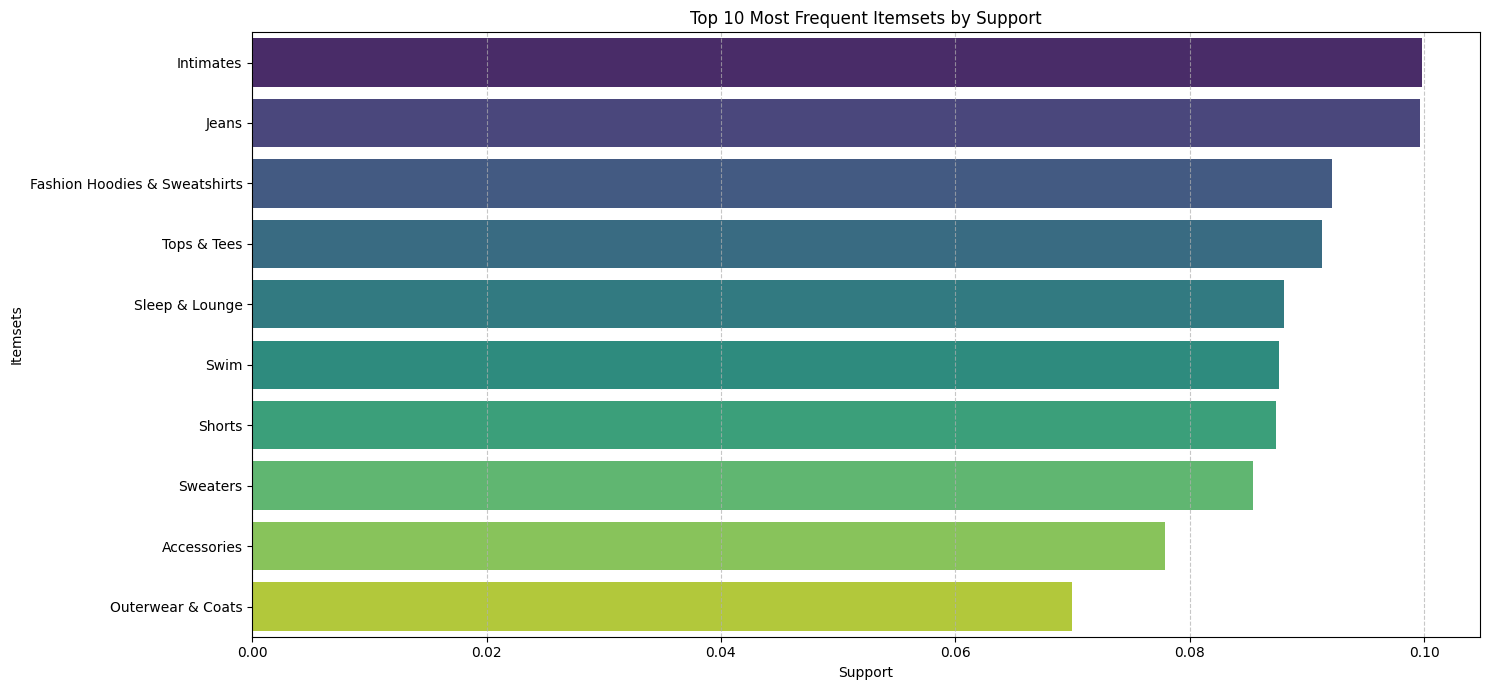

In [ ]:
frequent_itemsets['itemsets_str'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
top_frequent_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(15, 7))
sns.barplot(x='support', y='itemsets_str', data=top_frequent_items, palette='viridis')
plt.title('Top 10 Most Frequent Itemsets by Support')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

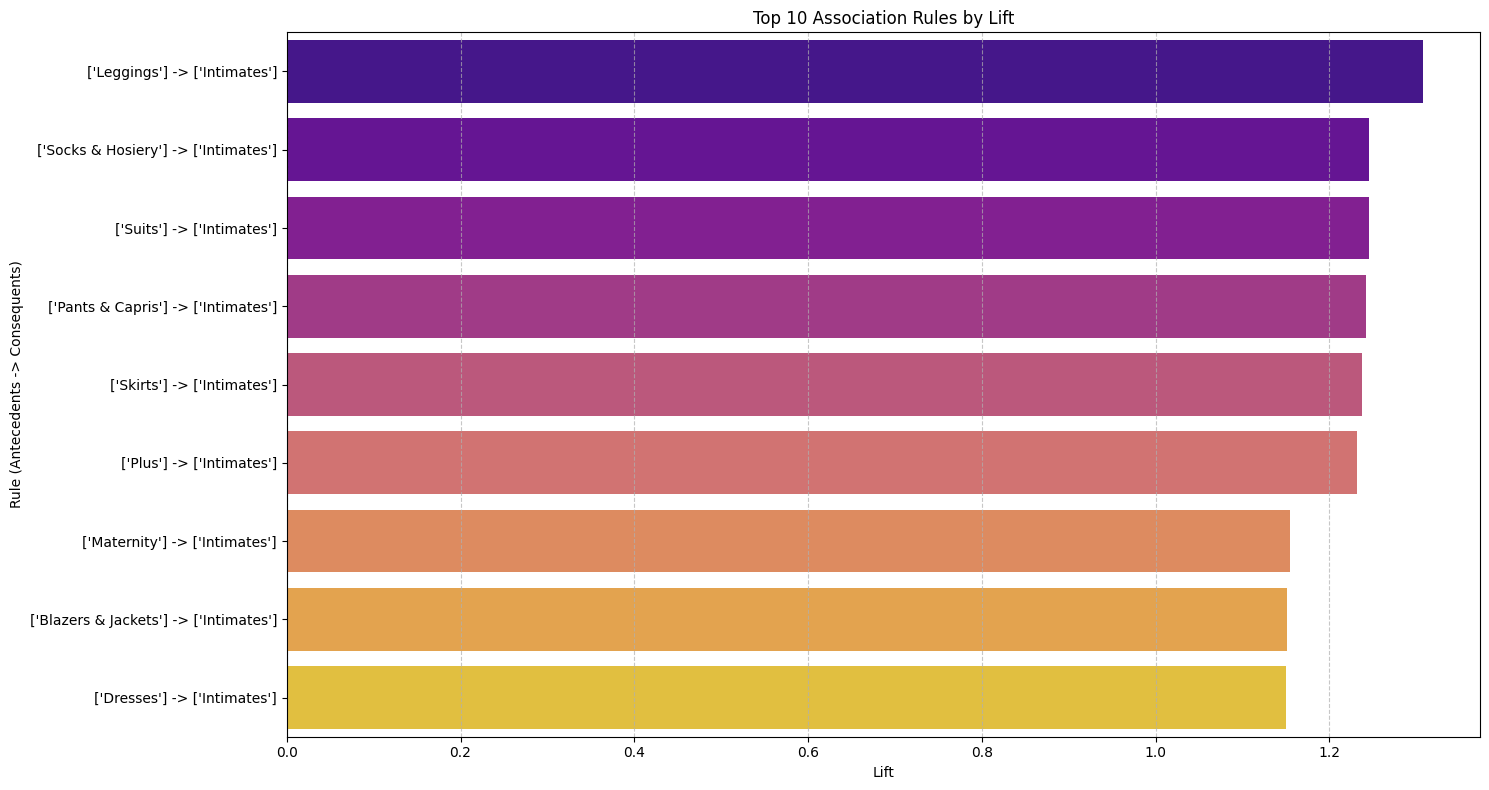

In [ ]:
rules['rule_str'] = rules.apply(lambda row: f"{list(row['antecedents'])} -> {list(row['consequents'])}", axis=1)
top_lift_rules = rules.sort_values(by='lift', ascending=False).head(10)

plt.figure(figsize=(15, 8))
sns.barplot(x='lift', y='rule_str', data=top_lift_rules, palette='plasma')
plt.title('Top 10 Association Rules by Lift')
plt.xlabel('Lift')
plt.ylabel('Rule (Antecedents -> Consequents)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Insight**

* Not only is Intimates the most popular product category, appearing in nearly 10% of total orders, but it also serves as the consequent in all of the Top 5 strongest association rules.

* Customers who purchase Leggings are 30.7% more likely to also purchase Intimates compared to the baseline probability (Lift = 1.3079). Similarly, categories such as Socks & Hosiery, Pants & Capris, and Skirts also increase the likelihood of purchasing Intimates by approximately 24%.

-> This indicates that customers rarely purchase Intimates as a standalone item. Instead, they tend to buy it together with other products as a complementary item, with a relatively high level of confidence.